## 🔷 STEP 1: Import Libraries


# 👉 Kya ho raha hai?
Hum tools load kar rahe hain jo data handle aur visualize karenge.

👉 Kyu use kiya?

pandas → data cleaning & manipulation
numpy → fast calculations
matplotlib/seaborn → visualization

👉 Kab use karte hain?
👉 Har data science project me FIRST STEP

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##🔷 STEP 2: Load Dataset

# 👉 Kya ho raha hai?
CSV file ko dataframe me convert kiya

👉 Kyu?
Machine learning model tabhi kaam karega jab data structured form me ho

👉 Output me dikkat?
Agar:

columns galat dikhe
numbers string ho

👉 matlab cleaning required

In [2]:
df = pd.read_csv("yahoo_data.csv")
df.head()


,Date,Open,High,Low,Close*,Adj Close**,Volume
0,"Apr 28, 2023","33,797.43","34,104.56","33,728.40","34,098.16","34,098.16","354,310,000"
1,"Apr 27, 2023","33,381.66","33,859.75","33,374.65","33,826.16","33,826.16","343,240,000"
2,"Apr 26, 2023","33,596.34","33,645.83","33,235.85","33,301.87","33,301.87","321,170,000"
3,"Apr 25, 2023","33,828.34","33,875.49","33,525.39","33,530.83","33,530.83","297,880,000"
4,"Apr 24, 2023","33,805.04","33,891.15","33,726.09","33,875.40","33,875.40","252,020,000"


#👉 Kya ho raha hai?

datatype check
missing values check
statistical summary

👉 Kyu important?
👉 Ye decide karta hai next steps kya honge

👉 Output analysis:

agar object datatype hai → convert karna padega
agar null values hain → handle karna padega

In [3]:
df.shape

(1258, 7)

# 👉 (a) Column Rename

👉 Kyu?
Messy column names coding me problem dete hain

👉 Best practice:
Clean & readable names

In [4]:
df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume']
df

,Date,Open,High,Low,Close,Adj_Close,Volume
0,"Apr 28, 2023","33,797.43","34,104.56","33,728.40","34,098.16","34,098.16","354,310,000"
1,"Apr 27, 2023","33,381.66","33,859.75","33,374.65","33,826.16","33,826.16","343,240,000"
2,"Apr 26, 2023","33,596.34","33,645.83","33,235.85","33,301.87","33,301.87","321,170,000"
3,"Apr 25, 2023","33,828.34","33,875.49","33,525.39","33,530.83","33,530.83","297,880,000"
4,"Apr 24, 2023","33,805.04","33,891.15","33,726.09","33,875.40","33,875.40","252,020,000"
...,...,...,...,...,...,...,...
1253,"May 07, 2018","24,317.66","24,479.45","24,263.42","24,357.32","24,357.32","307,670,000"
1254,"May 04, 2018","23,865.22","24,333.35","23,778.87","24,262.51","24,262.51","329,480,000"
1255,"May 03, 2018","23,836.23","23,996.15","23,531.31","23,930.15","23,930.15","389,240,000"
1256,"May 02, 2018","24,097.63","24,185.52","23,886.30","23,924.98","23,924.98","385,350,000"


## ✅ Remove commas + convert to numeric

# 👉 Kya ho raha hai?
"1,200" → 1200

👉 Kyu?
Model string pe kaam nahi karta

👉 Agar ye step skip kare?
❌ Model crash karega

In [5]:
cols = ['Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume']

for col in cols:
    df[col] = df[col].astype(str).str.replace(',', '')
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [6]:
df

,Date,Open,High,Low,Close,Adj_Close,Volume
0,"Apr 28, 2023",33797.43,34104.56,33728.40,34098.16,34098.16,354310000
1,"Apr 27, 2023",33381.66,33859.75,33374.65,33826.16,33826.16,343240000
2,"Apr 26, 2023",33596.34,33645.83,33235.85,33301.87,33301.87,321170000
3,"Apr 25, 2023",33828.34,33875.49,33525.39,33530.83,33530.83,297880000
4,"Apr 24, 2023",33805.04,33891.15,33726.09,33875.40,33875.40,252020000
...,...,...,...,...,...,...,...
1253,"May 07, 2018",24317.66,24479.45,24263.42,24357.32,24357.32,307670000
1254,"May 04, 2018",23865.22,24333.35,23778.87,24262.51,24262.51,329480000
1255,"May 03, 2018",23836.23,23996.15,23531.31,23930.15,23930.15,389240000
1256,"May 02, 2018",24097.63,24185.52,23886.30,23924.98,23924.98,385350000


### ✅ Convert Date

# 👉 Kya ho raha hai?
Date ko time-series format me convert

👉 Kyu?
Stock data = time dependent

👉 Kab use kare?
Jab bhi time-series data ho

In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

In [8]:
df.head()

,Open,High,Low,Close,Adj_Close,Volume
Date,,,,,,
2018-05-01,24117.29,24117.29,23808.19,24099.05,24099.05,380070000
2018-05-02,24097.63,24185.52,23886.30,23924.98,23924.98,385350000
2018-05-03,23836.23,23996.15,23531.31,23930.15,23930.15,389240000
2018-05-04,23865.22,24333.35,23778.87,24262.51,24262.51,329480000
2018-05-07,24317.66,24479.45,24263.42,24357.32,24357.32,307670000


# 🔷 STEP 5: Missing Values Handling

In [9]:
print(df.isnull().sum())

Open         0
High         0
Low          0
Close        0
Adj_Close    0
Volume       0
dtype: int64


# 🔥 STEP 6: EDA (Exploratory Data Analysis)

# 📊 1. Closing Price Trend


# 📊 Closing Price

👉 Kya dikha?
Trend (upar ya niche)

👉 Kyu important?
Model ko trend samajhna hota hai

👉 Output issue?

random noise → model difficult
clear trend → good 👍


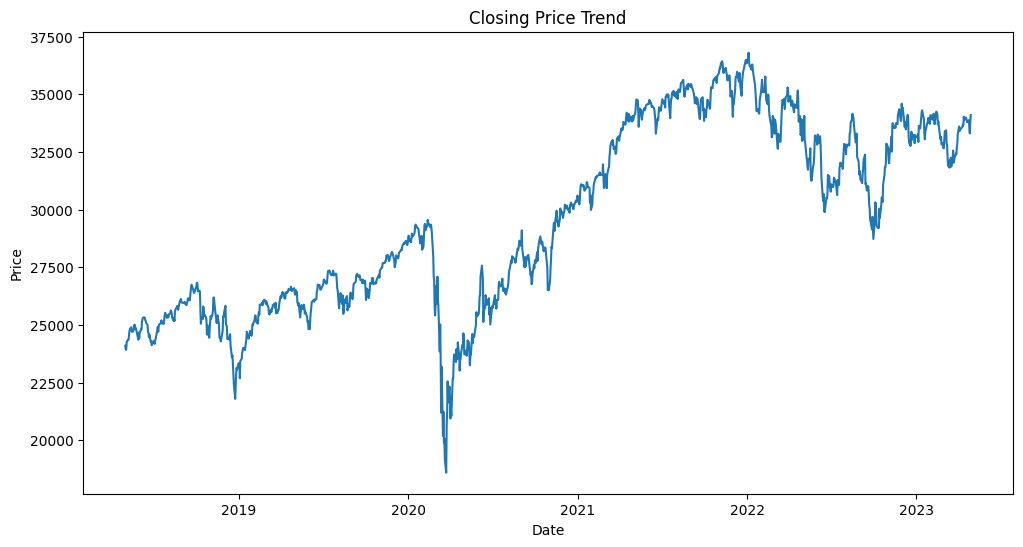

In [10]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title("Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

# 📊 2. Moving Averages

👉 Kya ho raha hai?
Price smooth ho raha hai

👉 Kyu?
Noise kam hota hai

👉 Kab use karte hain?
Finance me VERY COMMON

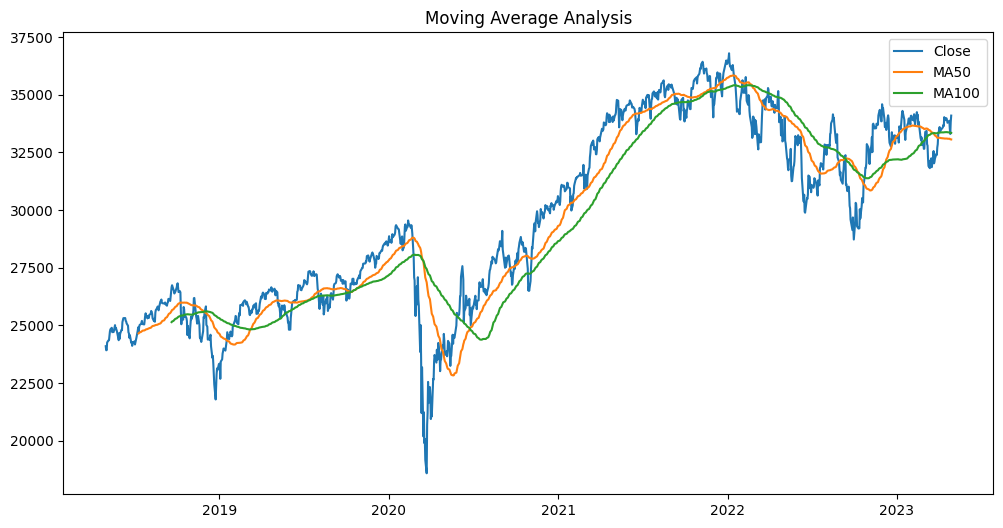

In [11]:
df['MA50'] = df['Close'].rolling(50).mean()
df['MA100'] = df['Close'].rolling(100).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close')
plt.plot(df['MA50'], label='MA50')
plt.plot(df['MA100'], label='MA100')
plt.legend()
plt.title("Moving Average Analysis")
plt.show()

# 📊 3. Volume Analysis

👉 Kya dikha?
Kitna trading ho raha hai

👉 Kyu important? kyunki

```
High volume = strong trend
```


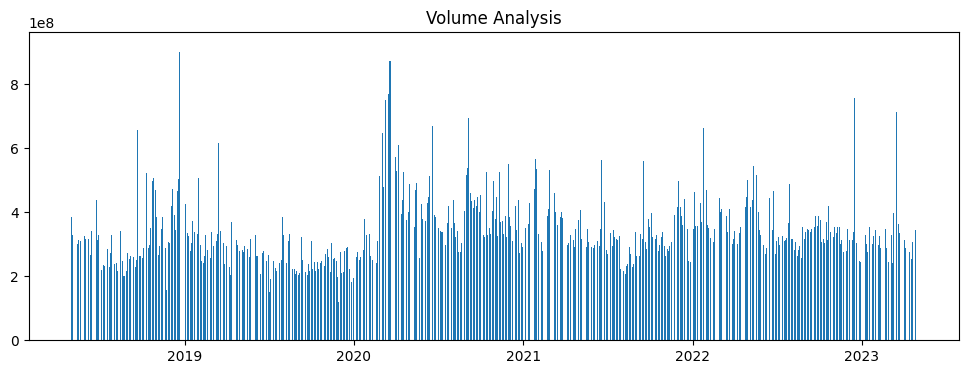

In [12]:
plt.figure(figsize=(12,4))
plt.bar(df.index, df['Volume'])
plt.title("Volume Analysis")
plt.show()

# 📊 4. Correlation Heatmap 🔥

👉 Kya ho raha hai?
Features ka relation check

👉 Kyu?
Redundant features avoid karne ke liye


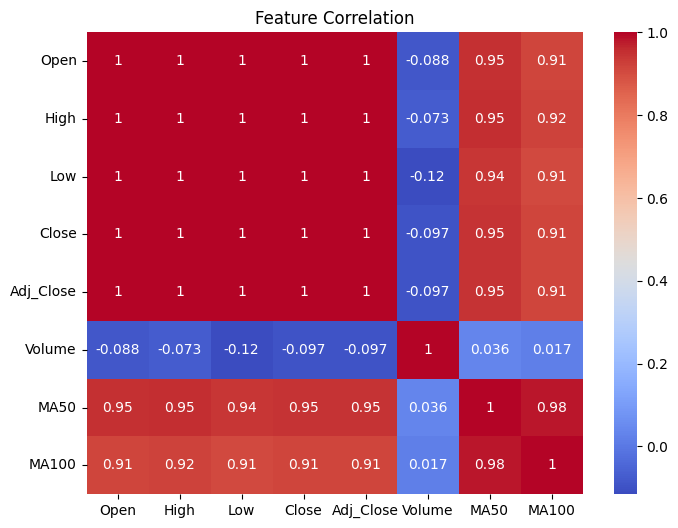

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# 🔥 STEP 7: Feature Engineering (MAJOR PROJECT LEVEL)

Return
```
👉 Return

👉 Meaning:
Price kitna change hua %

👉 Kyu?
Trend detection
```


Volatility


```
# 👉 Meaning:
Market kitna unstable hai

👉 Kyu?
Risk measurement
```



In [14]:
df['Return'] = df['Close'].pct_change()
df['Volatility'] = df['Return'].rolling(10).std()

df.dropna(inplace=True)

In [15]:
df.head()

,Open,High,Low,Close,Adj_Close,Volume,MA50,MA100,Return,Volatility
Date,,,,,,,,,,
2018-09-20,26519.39,26697.49,26519.39,26656.98,26656.98,260480000,25633.6016,25145.5998,0.009514,0.004637
2018-09-21,26726.25,26769.16,26680.37,26743.50,26743.50,657620000,25669.9738,25172.0443,0.003246,0.004203
2018-09-24,26705.25,26709.94,26548.68,26562.05,26562.05,254850000,25700.8266,25198.4150,-0.006785,0.005012
2018-09-25,26601.58,26634.85,26475.58,26492.21,26492.21,234110000,25729.3836,25224.0356,-0.002629,0.005235
2018-09-26,26536.86,26606.09,26349.34,26385.28,26385.28,262620000,25754.6914,25245.2633,-0.004036,0.005574


# 🔷 STEP 8: Feature Selection

In [16]:
data = df[['Close', 'Volume', 'MA50', 'MA100', 'Volatility']]

In [17]:
df.head()

,Open,High,Low,Close,Adj_Close,Volume,MA50,MA100,Return,Volatility
Date,,,,,,,,,,
2018-09-20,26519.39,26697.49,26519.39,26656.98,26656.98,260480000,25633.6016,25145.5998,0.009514,0.004637
2018-09-21,26726.25,26769.16,26680.37,26743.50,26743.50,657620000,25669.9738,25172.0443,0.003246,0.004203
2018-09-24,26705.25,26709.94,26548.68,26562.05,26562.05,254850000,25700.8266,25198.4150,-0.006785,0.005012
2018-09-25,26601.58,26634.85,26475.58,26492.21,26492.21,234110000,25729.3836,25224.0356,-0.002629,0.005235
2018-09-26,26536.86,26606.09,26349.34,26385.28,26385.28,262620000,25754.6914,25245.2633,-0.004036,0.005574


In [18]:
data.head()

,Close,Volume,MA50,MA100,Volatility
Date,,,,,
2018-09-20,26656.98,260480000,25633.6016,25145.5998,0.004637
2018-09-21,26743.50,657620000,25669.9738,25172.0443,0.004203
2018-09-24,26562.05,254850000,25700.8266,25198.4150,0.005012
2018-09-25,26492.21,234110000,25729.3836,25224.0356,0.005235
2018-09-26,26385.28,262620000,25754.6914,25245.2633,0.005574


# 🔷 STEP 9: Scaling

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [20]:
scaled_data

array([[0.44294673, 0.21007664, 0.21517256, 0.0690023 , 0.03542464],
       [0.44769856, 0.68865082, 0.21796971, 0.07139935, 0.02994178],
       [0.43773301, 0.2032922 , 0.2203424 , 0.0737897 , 0.04015787],
       ...,
       [0.80789577, 0.28321122, 0.78709187, 0.8132779 , 0.05176806],
       [0.8366907 , 0.30980671, 0.78668719, 0.81276227, 0.06533853],
       [0.85162942, 0.32314663, 0.78664121, 0.81246158, 0.06984127]])

# 🔥 STEP 10: Create Sequences (CORE LSTM)

In [21]:
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i])
        y.append(data[i, 0])  # Close price
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data)

In [22]:
X

array([[[0.44294673, 0.21007664, 0.21517256, 0.0690023 , 0.03542464],
        [0.44769856, 0.68865082, 0.21796971, 0.07139935, 0.02994178],
        [0.43773301, 0.2032922 , 0.2203424 , 0.0737897 , 0.04015787],
        ...,
        [0.32597931, 0.31112022, 0.19152725, 0.10862191, 0.17987097],
        [0.32982987, 0.25766413, 0.18817954, 0.10821681, 0.14667733],
        [0.3025409 , 0.39861901, 0.18398387, 0.10718217, 0.15954948]],

       [[0.44769856, 0.68865082, 0.21796971, 0.07139935, 0.02994178],
        [0.43773301, 0.2032922 , 0.2203424 , 0.0737897 , 0.04015787],
        [0.43389727, 0.17829943, 0.22253853, 0.07611207, 0.0429791 ],
        ...,
        [0.32982987, 0.25766413, 0.18817954, 0.10821681, 0.14667733],
        [0.3025409 , 0.39861901, 0.18398387, 0.10718217, 0.15954948],
        [0.27466646, 0.45863058, 0.1793166 , 0.10553142, 0.16022435]],

       [[0.43773301, 0.2032922 , 0.2203424 , 0.0737897 , 0.04015787],
        [0.43389727, 0.17829943, 0.22253853, 0.07611207, 0.0

In [23]:
y

array([0.27466646, 0.27920629, 0.25987493, ..., 0.80789577, 0.8366907 ,
       0.85162942])

In [24]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [25]:
X_train

array([[[0.44294673, 0.21007664, 0.21517256, 0.0690023 , 0.03542464],
        [0.44769856, 0.68865082, 0.21796971, 0.07139935, 0.02994178],
        [0.43773301, 0.2032922 , 0.2203424 , 0.0737897 , 0.04015787],
        ...,
        [0.32597931, 0.31112022, 0.19152725, 0.10862191, 0.17987097],
        [0.32982987, 0.25766413, 0.18817954, 0.10821681, 0.14667733],
        [0.3025409 , 0.39861901, 0.18398387, 0.10718217, 0.15954948]],

       [[0.44769856, 0.68865082, 0.21796971, 0.07139935, 0.02994178],
        [0.43773301, 0.2032922 , 0.2203424 , 0.0737897 , 0.04015787],
        [0.43389727, 0.17829943, 0.22253853, 0.07611207, 0.0429791 ],
        ...,
        [0.32982987, 0.25766413, 0.18817954, 0.10821681, 0.14667733],
        [0.3025409 , 0.39861901, 0.18398387, 0.10718217, 0.15954948],
        [0.27466646, 0.45863058, 0.1793166 , 0.10553142, 0.16022435]],

       [[0.43773301, 0.2032922 , 0.2203424 , 0.0737897 , 0.04015787],
        [0.43389727, 0.17829943, 0.22253853, 0.07611207, 0.0

In [26]:
y_train


array([0.27466646, 0.27920629, 0.25987493, 0.23438794, 0.2116377 ,
       0.17576446, 0.23542322, 0.24972319, 0.24552607, 0.26008363,
       0.26111507, 0.22486561, 0.26588886, 0.27128163, 0.28534709,
       0.29038177, 0.29712616, 0.29679828, 0.29206897, 0.30062303,
       0.30839831, 0.31734726, 0.3358147 , 0.31923547, 0.32863478,
       0.32740563, 0.33750903, 0.32603149, 0.32887314, 0.35275861,
       0.35192435, 0.35545142, 0.36508909, 0.37454387, 0.37337844,
       0.36125336, 0.3577823 , 0.35485937, 0.37532596, 0.38177982,
       0.37607454, 0.40045212, 0.40089533, 0.404362  , 0.39866057,
       0.40861129, 0.41191429, 0.41004859, 0.40604919, 0.4022508 ,
       0.40830977, 0.39695909, 0.39624401, 0.38893008, 0.3779331 ,
       0.37667045, 0.38768995, 0.38240538, 0.39054643, 0.39093363,
       0.39856391, 0.40214645, 0.40067894, 0.39289598, 0.40480521,
       0.37953077, 0.38032769, 0.38806616, 0.38630098, 0.39134664,
       0.40294721, 0.42105711, 0.41670237, 0.41884431, 0.42798

# 🔥 STEP 12: Build LSTM Model

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(100, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(Dropout(0.3))

model.add(LSTM(100, return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(50))
model.add(Dropout(0.3))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# 🔷 STEP 13: Train Model

In [28]:
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.0585
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.0113
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0099
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - loss: 0.0089
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - loss: 0.0083
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0091
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - loss: 0.0078
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - loss: 0.0075
Epoch 9/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - loss: 0.0076
Epoch 10/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step - loss: 0.0070
Epoch 11/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0073
Epoch 12/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - loss: 0.0072
Epoch 13/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step - loss: 0.0062
Epoch 14/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.0065
Epoch 15/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - lo

#🔥 STEP 14: Prediction

In [29]:
pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step


In [30]:
pred

array([[0.77864933],
       [0.7680883 ],
       [0.75418466],
       [0.73754275],
       [0.71644056],
       [0.69606185],
       [0.679261  ],
       [0.66689247],
       [0.658091  ],
       [0.6544918 ],
       [0.654974  ],
       [0.65924394],
       [0.6643968 ],
       [0.6705879 ],
       [0.6769474 ],
       [0.68344545],
       [0.68983406],
       [0.6963141 ],
       [0.7028229 ],
       [0.70786667],
       [0.71126354],
       [0.71248925],
       [0.7119099 ],
       [0.70999384],
       [0.7067972 ],
       [0.70363176],
       [0.7014528 ],
       [0.7002192 ],
       [0.7006389 ],
       [0.7016122 ],
       [0.70258915],
       [0.7041449 ],
       [0.70514506],
       [0.7073717 ],
       [0.7109541 ],
       [0.71553856],
       [0.7208726 ],
       [0.7270686 ],
       [0.7337108 ],
       [0.74023736],
       [0.7462878 ],
       [0.7517507 ],
       [0.756945  ],
       [0.762414  ],
       [0.7683272 ],
       [0.7743698 ],
       [0.7802095 ],
       [0.785

#🔷 STEP 15: Inverse Scaling

In [31]:
close_scaler = MinMaxScaler()
close_scaler.fit(df[['Close']])

pred = close_scaler.inverse_transform(pred.reshape(-1,1))
actual = close_scaler.inverse_transform(y_test.reshape(-1,1))

# 🔥 STEP 16: Evaluation

In [32]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(actual, pred))
print("RMSE:", rmse)


RMSE: 1009.4722771552534


# 🔷 STEP 17: Visualization

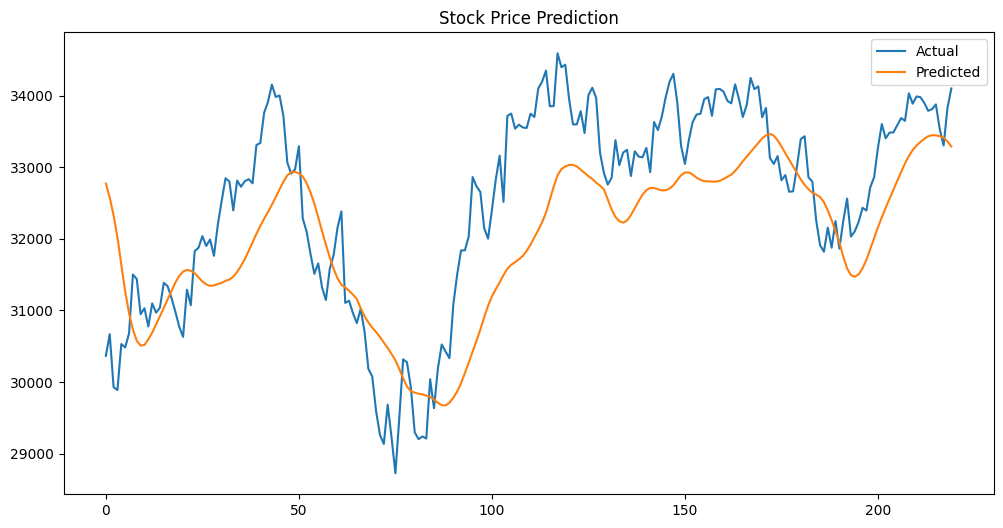

In [33]:
plt.figure(figsize=(12,6))
plt.plot(actual, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.title("Stock Price Prediction")
plt.show()

In [34]:
model.save("stock_model.h5")